# Simple machine learning model for MOFs

In [1]:
!wget "https://archive.materialscloud.org/records/nsp7v-2dk91/files/screening_data.tar.gz?download=1" -O dataset.tar.gz

--2026-07-10 13:43:50--  https://archive.materialscloud.org/records/nsp7v-2dk91/files/screening_data.tar.gz?download=1
Resolving archive.materialscloud.org (archive.materialscloud.org)... 148.187.24.210
Connecting to archive.materialscloud.org (archive.materialscloud.org)|148.187.24.210|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://rgw.cscs.ch/mc-archive/73/3e/60f9-8e55-4b65-9286-4b5f2d0aba66/data?response-content-type=application%2Foctet-stream&response-content-disposition=attachment%3B%20filename%3Dscreening_data.tar.gz&AWSAccessKeyId=3QPYIC2DSRF281L1K33M&Signature=uBbg3ggRCuzOhQ%2FC%2FniHBy9H77c%3D&Expires=1783691091 [following]
--2026-07-10 13:43:51--  https://rgw.cscs.ch/mc-archive/73/3e/60f9-8e55-4b65-9286-4b5f2d0aba66/data?response-content-type=application%2Foctet-stream&response-content-disposition=attachment%3B%20filename%3Dscreening_data.tar.gz&AWSAccessKeyId=3QPYIC2DSRF281L1K33M&Signature=uBbg3ggRCuzOhQ%2FC%2FniHBy9H77c%3D&Expires=178

In [2]:
!tar -xvf dataset.tar.gz

all_MOFs_screening_data.csv
top_MOFs_screening_data.csv


# Loading data

In [3]:
import pandas as pd

In [4]:
# Load dataset into a DataFrame
df = pd.read_csv('all_MOFs_screening_data.csv')

In [5]:
df.head(5)

,MOFname,CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_error_P0.15bar_T298K [mmol/g],heat_adsorption_CO2_P0.15bar_T298K [kcal/mol],heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol],excess_CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_P0.10bar_T363K [mmol/g],CO2_uptake_error_P0.10bar_T363K [mmol/g],heat_adsorption_CO2_P0.10bar_T363K [kcal/mol],heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol],...,void_fraction,void_volume [cm^3/g],largest_free_sphere_diameter [A],largest_included_sphere_along_free_sphere_path_diameter [A],largest_included_sphere_diameter [A],functional_groups,metal_linker,organic_linker1,organic_linker2,topology
0,str_m5_o16_o16_sra_sym.77,5.955197,0.117622,9.223227,0.546586,5.955127,0.840043,0.295803,7.972884,5.106942,...,0.14835,0.1480,4.61370,3.78047,4.61370,Pr,9,16,16,sra
1,str_m5_o16_o16_sra_sym.37,5.715251,0.034598,8.391884,0.149962,5.715251,0.901656,0.283054,8.343676,4.785696,...,0.16099,0.1624,4.10210,3.39756,4.10055,OMe,9,16,16,sra
2,str_m5_o13_o18_sra_sym.149,5.524486,0.155094,8.674098,0.753841,5.524486,0.688965,0.191963,7.546794,3.803472,...,0.17980,0.1810,4.24711,3.26179,4.24603,NO2,9,13,18,sra
3,str_m5_o2_o18_sra_sym.4,5.517258,0.084320,10.791553,0.514052,5.517258,1.881691,0.166854,9.246778,1.511943,...,0.10245,0.0922,4.11419,2.93595,3.63925,H,9,2,18,sra
4,str_m5_o16_o16_sra_sym.31,5.451593,0.051989,8.711414,0.260774,5.451476,0.797098,0.254966,8.247735,4.814885,...,0.15634,0.1583,4.37077,3.49681,4.16451,Et,9,16,16,sra


In [6]:
df.set_index('MOFname', inplace=True)

In [7]:
df.head(5)

,CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_error_P0.15bar_T298K [mmol/g],heat_adsorption_CO2_P0.15bar_T298K [kcal/mol],heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol],excess_CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_P0.10bar_T363K [mmol/g],CO2_uptake_error_P0.10bar_T363K [mmol/g],heat_adsorption_CO2_P0.10bar_T363K [kcal/mol],heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol],excess_CO2_uptake_P0.10bar_T363K [mmol/g],...,void_fraction,void_volume [cm^3/g],largest_free_sphere_diameter [A],largest_included_sphere_along_free_sphere_path_diameter [A],largest_included_sphere_diameter [A],functional_groups,metal_linker,organic_linker1,organic_linker2,topology
MOFname,,,,,,,,,,,,,,,,,,,,,
str_m5_o16_o16_sra_sym.77,5.955197,0.117622,9.223227,0.546586,5.955127,0.840043,0.295803,7.972884,5.106942,0.840004,...,0.14835,0.1480,4.61370,3.78047,4.61370,Pr,9,16,16,sra
str_m5_o16_o16_sra_sym.37,5.715251,0.034598,8.391884,0.149962,5.715251,0.901656,0.283054,8.343676,4.785696,0.901656,...,0.16099,0.1624,4.10210,3.39756,4.10055,OMe,9,16,16,sra
str_m5_o13_o18_sra_sym.149,5.524486,0.155094,8.674098,0.753841,5.524486,0.688965,0.191963,7.546794,3.803472,0.688965,...,0.17980,0.1810,4.24711,3.26179,4.24603,NO2,9,13,18,sra
str_m5_o2_o18_sra_sym.4,5.517258,0.084320,10.791553,0.514052,5.517258,1.881691,0.166854,9.246778,1.511943,1.881691,...,0.10245,0.0922,4.11419,2.93595,3.63925,H,9,2,18,sra
str_m5_o16_o16_sra_sym.31,5.451593,0.051989,8.711414,0.260774,5.451476,0.797098,0.254966,8.247735,4.814885,0.797034,...,0.15634,0.1583,4.37077,3.49681,4.16451,Et,9,16,16,sra


# Exploratory data analysis

In [8]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Simple histogram')

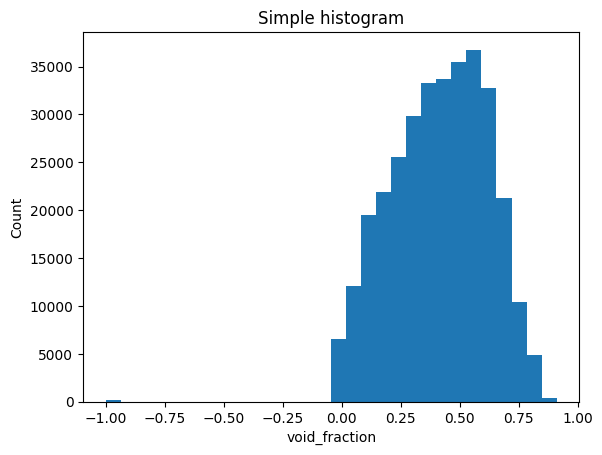

In [9]:
fig, ax = plt.subplots()

column = 'void_fraction'

ax.hist(df[column], bins=30);
ax.set_xlabel(column)
ax.set_ylabel('Count')
ax.set_title('Simple histogram')

# Training and test a model

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as RF

In [11]:
# Define the descriptors that will be used as input for the model.
descriptors = [
    'void_fraction', 'volume [A^3]',
    'weight [u]', 'surface_area [m^2/g]',
    'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]',
    'largest_included_sphere_diameter [A]',
]

#  Define the target property we want to predict.
target = 'CO2_uptake_P0.15bar_T298K [mmol/g]'

In [12]:
X = df[descriptors]
y = df[[target]]

# For reproducibility: random_state controls randomness
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.3, random_state=1)

In [13]:
# Create the RF algorithm
rf = RF(random_state=1, n_jobs=-1, n_estimators=5)

# Train it
rf.fit(X_train, y_train)

# Test it
score = rf.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [14]:
score

0.6490211160762901

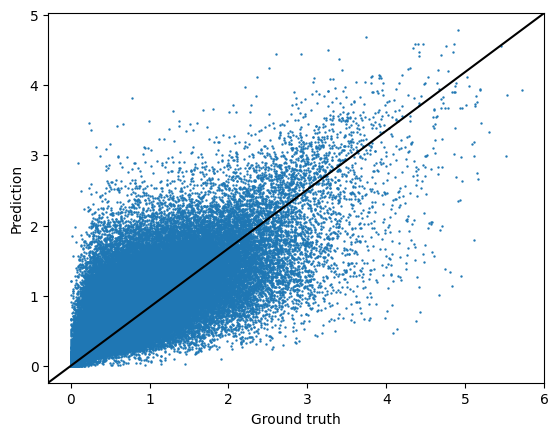

In [19]:
# Visualize predictions

preds = rf.predict(X_test)

fig, ax = plt.subplots()

ax.scatter(y_test, preds, s=0.5)
ax.plot([0, 1], [0, 1], transform=ax.transAxes, c='black')
ax.set_xlabel('Ground truth')
ax.set_ylabel('Prediction');